# Warm-starting INRs across images of the same digit

Train an INR on one image of digit `0`, then initialize the next INR with the previous one's weights and continue training on the next image of `0`. This is a small-scale (5 images) proof of concept before building a general autoregressive pipeline over all digits.

In [1]:
import os

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from dataset import OptimizedDataset
from model import mnistINR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

save_dir = os.path.join("checkpoints", "warmstart_zeros")
os.makedirs(save_dir, exist_ok=True)

Using device: cpu


## Pick 5 images of digit `0`

`OptimizedDataset` sorts samples by label, so the first samples in the dataset are all `0`s. We just take the first 5.

In [6]:
mnist_dataset = OptimizedDataset(as_inr=True)

num_samples = 5
samples = []
for i in range(num_samples):
    coords, target, label = mnist_dataset[i]
    assert label == 0, f"Expected digit 0 at index {i}, got {label}"
    samples.append((coords, target, label))

print(f"Collected {len(samples)} images of digit 0")

Collected 5 images of digit 0


## Training helper

Same loop as `train.py`: train until the loss drops below `0.002` or `10000` epochs are reached. Returns the loss history so we can plot convergence.

In [7]:
def train_inr(model, coords, target, lr=1e-3, loss_threshold=0.002, max_epochs=10000, log_every=500):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    loss_history = []
    epoch = 1
    while True:
        optimizer.zero_grad()
        prediction = model(coords)
        loss = criterion(prediction, target)
        loss_history.append(loss.item())

        if loss.item() < loss_threshold or epoch > max_epochs:
            break

        loss.backward()
        optimizer.step()

        if epoch % log_every == 0:
            print(f"  Epoch {epoch} | Loss: {loss.item():.6f}")
        epoch += 1

    return loss_history

## Sequential warm-start training

Each model is initialized with the previous model's weights (except the first, which starts from a random init). We keep the trained models, their loss histories, and save each checkpoint.

In [8]:
prev_weights = None
trained_models = []
loss_histories = []

for i, (coords, target, label) in enumerate(samples):
    coords = coords.to(device)
    target = target.to(device)

    model = mnistINR().to(device)
    if prev_weights is not None:
        print(f"Sample #{i}: warm-starting from sample #{0}'s weights")
        model.load_state_dict(prev_weights)
    else:
        print(f"Sample #{i}: training from a random initialization")

    loss_history = train_inr(model, coords, target)
    print(f"  -> Finished after {len(loss_history)} epochs | Final loss: {loss_history[-1]:.6f}")

    save_path = os.path.join(save_dir, f"model_sample_{i}_digit_{label}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"  -> Saved checkpoint to '{save_path}'")

    trained_models.append(model)
    loss_histories.append(loss_history)
    if prev_weights is None:
        prev_weights = model.state_dict()

Sample #0: training from a random initialization
  Epoch 500 | Loss: 0.010020
  -> Finished after 885 epochs | Final loss: 0.001998
  -> Saved checkpoint to 'checkpoints/warmstart_zeros/model_sample_0_digit_0.pth'
Sample #1: warm-starting from sample #0's weights
  -> Finished after 297 epochs | Final loss: 0.001998
  -> Saved checkpoint to 'checkpoints/warmstart_zeros/model_sample_1_digit_0.pth'
Sample #2: warm-starting from sample #0's weights
  -> Finished after 493 epochs | Final loss: 0.001997
  -> Saved checkpoint to 'checkpoints/warmstart_zeros/model_sample_2_digit_0.pth'
Sample #3: warm-starting from sample #0's weights
  Epoch 500 | Loss: 0.002780
  -> Finished after 680 epochs | Final loss: 0.001997
  -> Saved checkpoint to 'checkpoints/warmstart_zeros/model_sample_3_digit_0.pth'
Sample #4: warm-starting from sample #0's weights
  -> Finished after 439 epochs | Final loss: 0.001993
  -> Saved checkpoint to 'checkpoints/warmstart_zeros/model_sample_4_digit_0.pth'


## Loss curves

If warm-starting helps, later samples should converge faster (fewer epochs / lower starting loss) than the first one.

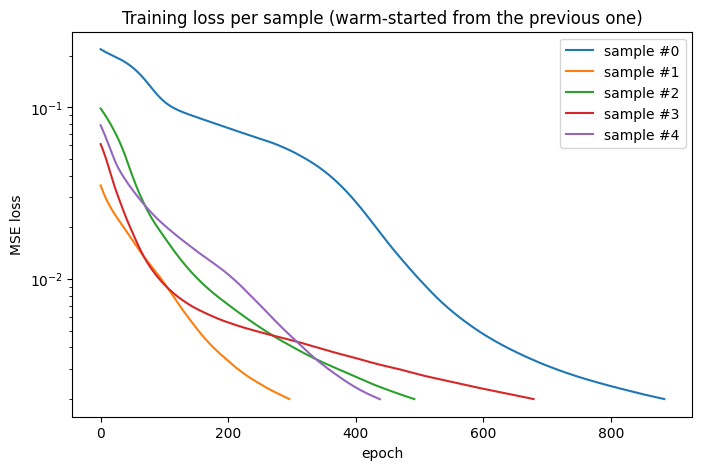

In [9]:
plt.figure(figsize=(8, 5))
for i, loss_history in enumerate(loss_histories):
    plt.plot(loss_history, label=f"sample #{i}")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.yscale("log")
plt.title("Training loss per sample (warm-started from the previous one)")
plt.legend()
plt.show()

## Reconstructed images vs. ground truth

Render each trained INR over its input coordinate grid and compare it to the original MNIST image.

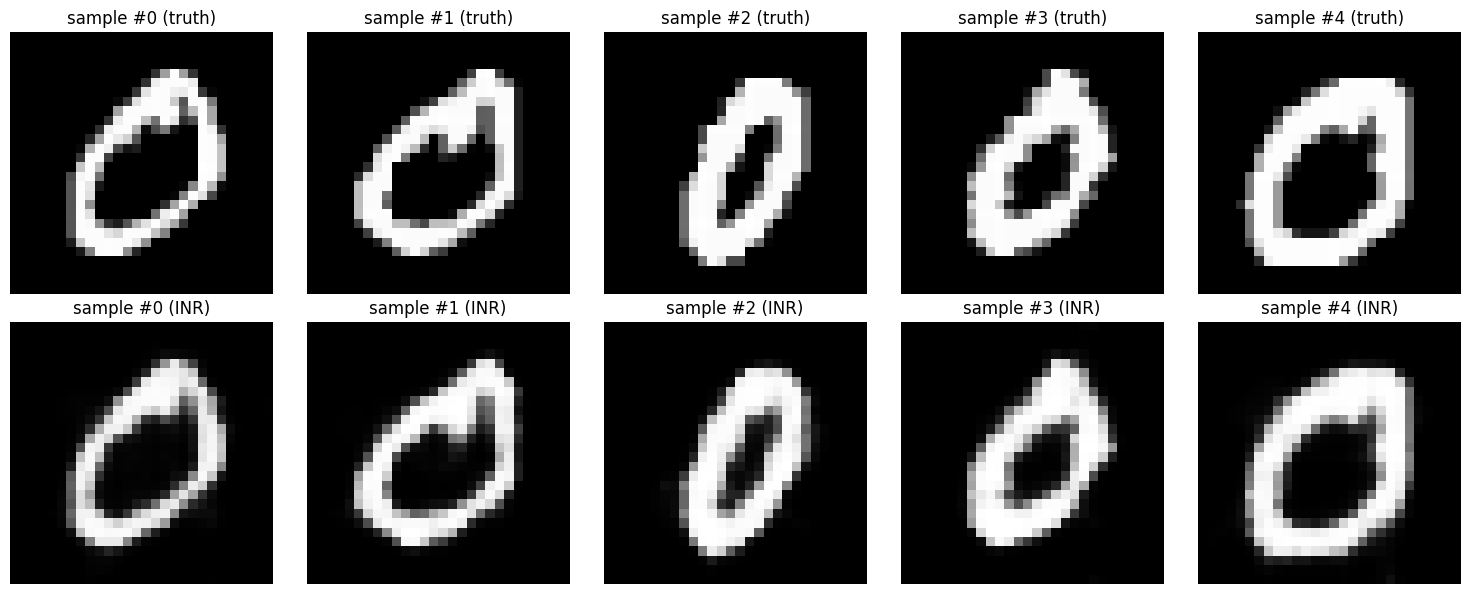

In [10]:
fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))

for i, ((coords, target, label), model) in enumerate(zip(samples, trained_models)):
    side = int(target.shape[0] ** 0.5)

    with torch.no_grad():
        prediction = model(coords.to(device)).cpu().reshape(side, side)
    ground_truth = target.reshape(side, side)

    axes[0, i].imshow(ground_truth, cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"sample #{i} (truth)")
    axes[0, i].axis("off")

    axes[1, i].imshow(prediction, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"sample #{i} (INR)")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## General pipeline: warm-start across all 10 digits

Generalize the idea: for **each digit 0-9**, train an INR from scratch on the first image of that digit, then use *that same base model's weights* to initialize the INRs for the remaining images of the digit. Unlike the chained experiment above, every sample within a digit warm-starts from the digit's own base model (sample #0), not from its immediate predecessor.

In [11]:
num_digits = 10
samples_per_digit = 5

digit_samples = {d: [] for d in range(num_digits)}
idx = 0
while any(len(v) < samples_per_digit for v in digit_samples.values()):
    coords, target, label = mnist_dataset[idx]
    if len(digit_samples[label]) < samples_per_digit:
        digit_samples[label].append((coords, target, label))
    idx += 1

for d in range(num_digits):
    print(f"Digit {d}: collected {len(digit_samples[d])} samples")

Digit 0: collected 5 samples
Digit 1: collected 5 samples
Digit 2: collected 5 samples
Digit 3: collected 5 samples
Digit 4: collected 5 samples
Digit 5: collected 5 samples
Digit 6: collected 5 samples
Digit 7: collected 5 samples
Digit 8: collected 5 samples
Digit 9: collected 5 samples


## Train each digit, warm-starting from its own base model

For every digit: train sample #0 from a random init (the base model), then warm-start samples #1.. from the base model's weights. Checkpoints are saved to `checkpoints/warmstart_all_digits/`.

In [ ]:
all_save_dir = os.path.join("checkpoints", "warmstart_all_digits")
os.makedirs(all_save_dir, exist_ok=True)

all_trained_models = {}
all_loss_histories = {}

for digit in range(num_digits):
    print(f"=== Digit {digit} ===")
    base_weights = None
    trained_models = []
    loss_histories = []

    for i, (coords, target, label) in enumerate(digit_samples[digit]):
        coords = coords.to(device)
        target = target.to(device)

        model = mnistINR().to(device)
        if base_weights is not None:
            print(f"  Sample #{i}: warm-starting from digit {digit}'s base model (sample #0)")
            model.load_state_dict(base_weights)
        else:
            print(f"  Sample #{i}: training from a random init (becomes the base model for digit {digit})")

        loss_history = train_inr(model, coords, target)
        print(f"    -> Finished after {len(loss_history)} epochs | Final loss: {loss_history[-1]:.6f}")

        save_path = os.path.join(all_save_dir, f"digit_{digit}_sample_{i}.pth")
        torch.save(model.state_dict(), save_path)

        trained_models.append(model)
        loss_histories.append(loss_history)
        if base_weights is None:
            base_weights = model.state_dict()

    all_trained_models[digit] = trained_models
    all_loss_histories[digit] = loss_histories

=== Digit 0 ===
  Sample #0: training from a random init (becomes the base model for digit 0)
  Epoch 500 | Loss: 0.014581
    -> Finished after 937 epochs | Final loss: 0.002000
  Sample #1: warm-starting from digit 0's base model (sample #0)
    -> Finished after 262 epochs | Final loss: 0.001994
  Sample #2: warm-starting from digit 0's base model (sample #0)
    -> Finished after 470 epochs | Final loss: 0.001997
  Sample #3: warm-starting from digit 0's base model (sample #0)
  Epoch 500 | Loss: 0.002497
    -> Finished after 639 epochs | Final loss: 0.001997
  Sample #4: warm-starting from digit 0's base model (sample #0)
  Epoch 500 | Loss: 0.002147
    -> Finished after 522 epochs | Final loss: 0.001998
=== Digit 1 ===
  Sample #0: training from a random init (becomes the base model for digit 1)
  Epoch 500 | Loss: 0.007020
    -> Finished after 699 epochs | Final loss: 0.001993
  Sample #1: warm-starting from digit 1's base model (sample #0)
    -> Finished after 410 epochs | 

## Loss curves per digit

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
for digit in range(num_digits):
    ax = axes[digit // 5, digit % 5]
    for i, loss_history in enumerate(all_loss_histories[digit]):
        ax.plot(loss_history, label=f"sample #{i}")
    ax.set_yscale("log")
    ax.set_title(f"digit {digit}")
    ax.set_xlabel("epoch")
    if digit % 5 == 0:
        ax.set_ylabel("MSE loss")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Epochs to converge, per digit and sample

If warm-starting from the digit's base model helps, samples #1.. should generally need fewer epochs than sample #0 (the from-scratch base model).

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
width = 0.8 / samples_per_digit
x = list(range(num_digits))

for i in range(samples_per_digit):
    epochs = [len(all_loss_histories[d][i]) for d in range(num_digits)]
    offsets = [xi + i * width for xi in x]
    ax.bar(offsets, epochs, width=width, label=f"sample #{i}")

ax.set_xticks([xi + width * (samples_per_digit - 1) / 2 for xi in x])
ax.set_xticklabels([str(d) for d in range(num_digits)])
ax.set_xlabel("digit")
ax.set_ylabel("epochs to converge")
ax.set_title("Epochs needed to reach the loss threshold")
ax.legend()
plt.show()

## Reconstructed images vs. ground truth, per digit

In [ ]:
fig, axes = plt.subplots(num_digits, samples_per_digit, figsize=(3 * samples_per_digit, 3 * num_digits))

for digit in range(num_digits):
    for i, ((coords, target, label), model) in enumerate(zip(digit_samples[digit], all_trained_models[digit])):
        side = int(target.shape[0] ** 0.5)
        with torch.no_grad():
            prediction = model(coords.to(device)).cpu().reshape(side, side)

        axes[digit, i].imshow(prediction, cmap="gray", vmin=0, vmax=1)
        axes[digit, i].set_title(f"digit {digit} | sample #{i}")
        axes[digit, i].axis("off")

plt.tight_layout()
plt.show()